<a href="https://colab.research.google.com/github/fathinahnj/skripsi/blob/main/waste_classification_skripsi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import

In [1]:
%%capture
!pip install roboflow

In [3]:
%%capture
!pip install -q inference-gpu
!pip install -q trackers[sort]
!pip install -q supervision==0.27.0

In [5]:
!pip install sympy
!pip install torch torchvision

In [6]:
%%capture
!pip install --upgrade ultralytics

In [17]:
%%capture
!pip install deep-sort-realtime
!pip install opencv-python
!pip install numpy

# Dataset

In [7]:
%%capture
from roboflow import Roboflow
rf = Roboflow(api_key="Wi7nmEb34BK9rtJ1O27x")
project = rf.workspace("organic-an-organic").project("river-waste-classification-saya")
version = project.version(5)
dataset = version.download("yolov8")


# Train

In [8]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLOv8n model
model = YOLO("yolov8n.pt")

# Train the model on the COCO8 example dataset for 100 epochs
# results = model.train(data='/content/River-Waste-Classification-Saya-5/data.yaml', epochs=250, imgsz=640)

# Val

In [9]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolov8n.pt")  # load an official model
model = YOLO("/content/drive/MyDrive/SKRIPSI/runs (v3)/runs (v3)/detect/train/weights/best.pt")  # load a custom model

# Validate the model
metrics = model.val(data='/content/River-Waste-Classification-Saya-5/data.yaml')  # Specify the correct data.yaml path
metrics.box.map  # map50-95
metrics.box.map50  # map50
metrics.box.map75  # map75
metrics.box.maps  # a list containing mAP50-95 for each category

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.1 ms, read: 26.2±12.7 MB/s, size: 56.0 KB)
val: Scanning /content/River-Waste-Classification-Saya-5/valid/labels... 94 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 94/94 629.9it/s 0.1s
val: New cache created: /content/River-Waste-Classification-Saya-5/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.3it/s 4.7s
                   all         94        963      0.787      0.744      0.799      0.548
           Non-Plastic         91        498      0.741      0.689      0.746      0.499
               Plastic         84        465      0.834        0.8      0.852      0.597
Speed: 4.3ms preprocess, 5.2ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/detect/val


array([    0.49907,      0.5971])

# Save Model

In [7]:
#%cp -r '/content/runs (v3.2)' /content/drive/MyDrive/SKRIPSI

In [8]:
%cd /content/drive/MyDrive/SKRIPSI
%ls

/content/drive/MyDrive/SKRIPSI
 dataset_crop_1to1/         hasil_video2/        'runs (v3)'/
 dataset_crop_1to1_part2/  'null images (raw)'/  'runs (v3.2)'/
'dataset dari wina'/        runs/                'sungai saddang.mp4'
 hasil_video/              'runs (v2)'/          'sungai tallo tol.mp4'


# Predict

In [10]:
from ultralytics import YOLO

YOLO("/content/drive/MyDrive/SKRIPSI/runs (v3)/runs (v3)/detect/train/weights/best.pt")


YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

In [11]:
%%capture
model.predict(
    source="/content/drive/MyDrive/SKRIPSI/hasil_video/DJI_20260217145424_0015_D.MP4",   # video dari drive
    save=True,
    project="/content/drive/MyDrive/SKRIPSI/hasil_video/hasil_video",     # folder output di drive
    conf=0.45,
    stream=False
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1376) /content/drive/MyDrive/SKRIPSI/hasil_video/DJI_20260217145424_0015_D.MP4: 384x640 1 Non-Plastic, 2 Plastics, 39.8ms
video 1/1 (frame 2/1376) /content/drive/MyDrive/SKRIPSI/hasil_video/DJI_20260217145424_0015_D.MP4: 384x640 1 Non-Plastic, 3 Plastics, 10.6ms
video 1/1 (frame 3/1376) /content/drive/MyDrive/SKRIPSI/hasil_video/DJI_20260217145424_0015_D.MP4: 384x640 2 Non-Plastics, 3 Plastics, 9.6ms
video 1/1 (frame 4/1376) /content/d

# Track Object

In [18]:
import cv2
import numpy as np
from deep_sort_realtime.deepsort_tracker import DeepSort

In [19]:
model = YOLO("/content/drive/MyDrive/SKRIPSI/runs (v3)/runs (v3)/detect/train/weights/best.pt")

tracker = DeepSort(
    max_age=30,
    n_init=3,
    max_cosine_distance=0.4
)

In [30]:
%cd /content/drive/MyDrive/SKRIPSI/hasil_video/hasil_video
%ls

/content/drive/MyDrive/SKRIPSI/hasil_video/hasil_video
 predict/    predict3/  'Recording 2026-02-13 115518.avi'
 predict2/   predict4/


In [44]:
cap = cv2.VideoCapture("/predict4/DJI_20260217145424_0015_D.avi")
# cap = cv2.VideoCapture(0)

In [45]:
while True:
    ret, frame = cap.read()

    if not ret:
        break

    results = model(frame)[0]

    detections = []

    for r in results.boxes.data:
        x1, y1, x2, y2, conf, cls = r

        if conf > 0.5:
            detections.append(
                ([x1, y1, x2-x1, y2-y1], conf, int(cls))
            )

    tracks = tracker.update_tracks(
        detections,
        frame=frame
    )

    for track in tracks:

        if not track.is_confirmed():
            continue

        track_id = track.track_id
        l, t, r, b = track.to_ltrb()

        x1 = int(l)
        y1 = int(t)
        x2 = int(r)
        y2 = int(b)

        cv2.rectangle(frame,(x1,y1),(x2,y2),(0,255,0),2)

        cv2.putText(
            frame,
            f"ID {track_id}",
            (x1,y1-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0,255,0),
            2
        )

    cv2.imshow("Tracking", frame)

    if cv2.waitKey(1) == 27:
        break


In [46]:
cap.release()
cv2.destroyAllWindows()

In [53]:
from inference import get_model
from trackers import DeepSORTFeatureExtractor, DeepSORTTracker

model = YOLO("/content/drive/MyDrive/SKRIPSI/runs (v3)/runs (v3)/detect/train/weights/best.pt")

feature_extractor = DeepSORTFeatureExtractor.from_timm(
    model_name="mobilenetv4_conv_small.e1200_r224_in1k")

tracker = DeepSORTTracker(feature_extractor=feature_extractor)

ImportError: cannot import name 'DeepSORTFeatureExtractor' from 'trackers' (/usr/local/lib/python3.12/dist-packages/trackers/__init__.py)

In [41]:
CONFIDENCE_THRESHOLD = 0.3
NMS_THRESHOLD = 0.3

SOURCE_VIDEO_PATH = "/content/drive/MyDrive/SKRIPSI/hasil_video/DJI_20260217145424_0015_D.MP4"
TARGET_VIDEO_PATH = "/content/drive/MyDrive/SKRIPSI/hasil_video/tracking"

https://trackers.roboflow.com/develop/learn/track/#trackers

In [54]:
trackers track \
    --source SOURCE_VIDEO_PATH \
    --model rfdetr-nano \
    --tracker sort \
    --display \
    --show-confidence \
    --show-labels \
    --output TARGET_VIDEO_PATH

SyntaxError: invalid syntax (8019708.py, line 1)

In [55]:
import cv2

import supervision as sv
from inference import get_model
from trackers import sort

model = get_model(model)
tracker = sort(
    lost_track_buffer=60,
    minimum_consecutive_frames=5,
)

cap = cv2.VideoCapture(SOURCE_VIDEO_PATH)
while True:
    ret, frame = cap.read()
    if not ret:
        break

    result = model.infer(frame)[0]
    detections = sv.Detections.from_inference(result)
    detections = tracker.update(detections)

ImportError: cannot import name 'sort' from 'trackers' (/usr/local/lib/python3.12/dist-packages/trackers/__init__.py)

In [33]:
import supervision as sv

color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

box_annotator = sv.BoxAnnotator(
    color=color,
    color_lookup=sv.ColorLookup.TRACK)

trace_annotator = sv.TraceAnnotator(
    color=color,
    color_lookup=sv.ColorLookup.TRACK,
    thickness=2,
    trace_length=100)

label_annotator = sv.LabelAnnotator(
    color=color,
    color_lookup=sv.ColorLookup.TRACK,
    text_color=sv.Color.BLACK,
    text_scale=0.8)

In [42]:
frame_samples = []

def callback(frame, i):
    result = model.infer(frame, confidence=CONFIDENCE_THRESHOLD)[0]
    detections = sv.Detections.from_inference(result).with_nms(threshold=NMS_THRESHOLD)
    detections = tracker.update(detections, frame=frame)

    annotated_image = frame.copy()
    annotated_image = box_annotator.annotate(annotated_image, detections)
    annotated_image = trace_annotator.annotate(annotated_image, detections)
    annotated_image = label_annotator.annotate(annotated_image, detections, detections.tracker_id)

    if i % 30 == 0 and i != 0:
        frame_samples.append(annotated_image)

    return annotated_image

# tracker.reset()

In [43]:
sv.process_video(
    source_path=SOURCE_VIDEO_PATH,
    target_path=TARGET_VIDEO_PATH,
    callback=callback,
    show_progress=True,
)

Processing video:   0%|          | 0/1376 [00:00<?, ?it/s]

KeyboardInterrupt: 

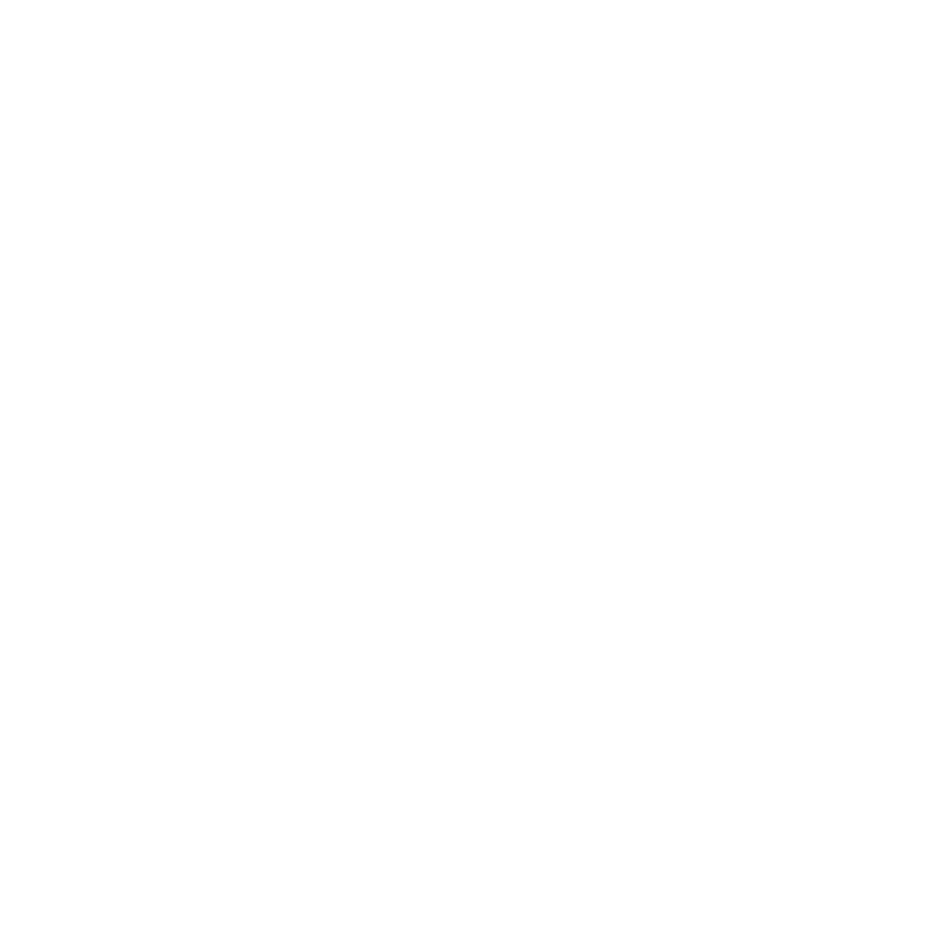

In [40]:
sv.plot_images_grid(images=frame_samples[:4], grid_size=(2, 2))